# Aula 5 — Modelagem de um detector de malware

## Das features estáticas ao modelo pronto para o Splunk

Nesta aula vamos construir um detector de malware usando **features já extraídas de executáveis Windows**. Não vamos baixar nem executar malware.

O objetivo não é obter o maior número possível, mas entender o ciclo completo:

1. carregar uma base real e aberta;
2. escolher features com significado para segurança;
3. separar treino, validação e teste sem usar o teste para ajustar decisões;
4. treinar um baseline e um Random Forest;
5. escolher o limiar pelo custo dos erros;
6. investigar quais sinais o modelo usou;
7. exportar um CSV compatível com o laboratório no Splunk.

## Base utilizada

Usaremos **Malware Static and Dynamic Features VxHeaven and VirusTotal**, disponibilizada no UCI Machine Learning Repository.

- 595 arquivos benignos coletados em diretórios *Program Files* do Windows 7 e 8;
- 2.698 amostras de malware do VxHeaven;
- 2.955 amostras fornecidas pelo VirusTotal em 2018;
- aproximadamente 1.087 features estáticas e dinâmicas;
- licença **CC BY 4.0**;
- DOI: https://doi.org/10.24432/C58K6H

> **Limitação importante:** benignos e maliciosos vieram de fontes diferentes. O modelo pode aprender características da coleta — e não apenas de malware. Vamos tratar isso como parte da análise.

## Segurança do laboratório

O arquivo baixado contém apenas tabelas CSV de features. Não há executáveis no notebook.

- Não baixem amostras binárias de malware.
- Não tentem reproduzir as features executando arquivos desconhecidos.
- Para estudos com binários, seria necessário um laboratório isolado, autorização e procedimentos específicos.
- No Splunk, carregaremos somente vetores numéricos.

In [1]:
# Bibliotecas — o Colab normalmente já possui todas elas
import io, os, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')

## 1. Baixar a base real

O download vem diretamente do UCI. São três CSVs e nenhum arquivo executável.

In [2]:
URL = 'https://archive.ics.uci.edu/static/public/541/malware+static+and+dynamic+features+vxheaven+and+virus+total.zip'
# No Colab usa /content; localmente usa a pasta de trabalho do notebook
BASE_DIR = Path('/content') if Path('/content').is_dir() else Path.cwd()
PASTA = BASE_DIR / 'uci_malware_541'
ZIP = BASE_DIR / 'uci_malware_541.zip'

PASTA.mkdir(parents=True, exist_ok=True)
if not ZIP.exists():
    print('Baixando a base do UCI...')
    urllib.request.urlretrieve(URL, ZIP)

with zipfile.ZipFile(ZIP) as z:
    z.extractall(PASTA)

arquivos = sorted(PASTA.glob('*.csv'))
print('Arquivos encontrados:')

for arq in arquivos:    print(' -', arq.name, f'({arq.stat().st_size/1e6:.1f} MB)')

Arquivos encontrados:
 - staDynBenignLab.csv (1.5 MB)
 - staDynVt2955Lab.csv (7.6 MB)
 - staDynVxHeaven2698Lab.csv (6.6 MB)


## 2. Carregar e alinhar os três conjuntos

Os CSVs não têm exatamente as mesmas colunas. Vamos conservar apenas as features presentes em todos eles e registrar a origem de cada linha para auditoria.

In [3]:
partes = [(pd.read_csv(arq), arq.stem) for arq in arquivos]

colunas_comuns = sorted(set.intersection(*[set(p.columns) for p, _ in partes]))
df = pd.concat(
    [p[colunas_comuns].copy().assign(source_dataset=nome) for p, nome in partes],
    ignore_index=True
)

# Identificador interno — não será usado como feature
df = df.assign(sample_id=np.arange(len(df)))
df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)

print('Dimensões:', df.shape)
print('Colunas comuns:', len(colunas_comuns))
print(df.groupby(['source_dataset', 'label']).size())

Dimensões: (6248, 1087)
Colunas comuns: 1085
source_dataset         label
staDynBenignLab        0         595
staDynVt2955Lab        1        2955
staDynVxHeaven2698Lab  1        2698
dtype: int64


### O primeiro alerta de qualidade

Observe a tabela acima: a origem do arquivo praticamente determina o rótulo. Isso significa que **source_dataset, filename, hash, caminho e índice jamais devem entrar no modelo**.

Mesmo removendo esses campos, outras features podem carregar marcas indiretas da origem. Um bom resultado neste dataset deve ser interpretado como demonstração didática, não como garantia de desempenho em produção.

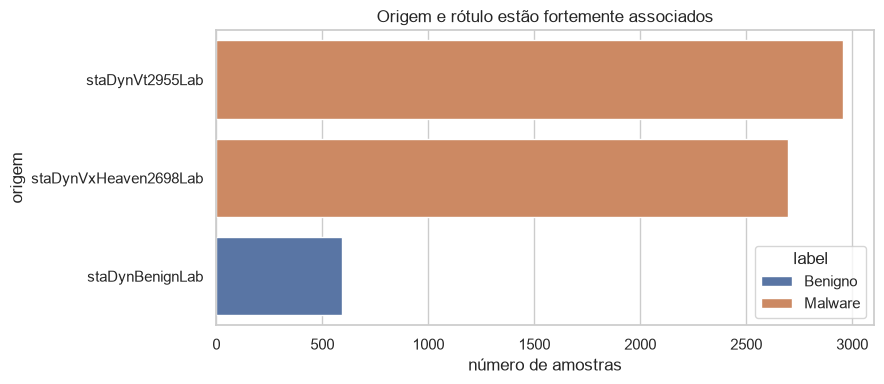

Proporção de malware: 90.5%


In [4]:
plt.figure(figsize=(9, 4))
ordem = df['source_dataset'].value_counts().index
sns.countplot(data=df, y='source_dataset', hue='label', order=ordem)
plt.title('Origem e rótulo estão fortemente associados')
plt.xlabel('número de amostras')
plt.ylabel('origem')
plt.legend(title='label', labels=['Benigno', 'Malware'])
plt.tight_layout()
plt.show()

print('Proporção de malware:', f"{df['label'].mean():.1%}")

## 3. Escolher features com significado

Em vez de entregar mais de mil colunas ao modelo, começaremos com um conjunto pequeno e auditável.

### Famílias escolhidas

- **Estrutura PE:** tamanho, número de seções, entry point e alinhamentos.
- **Entropia e seções:** entropia e tamanho de regiões conhecidas.
- **Imports/capacidades:** presença de APIs ligadas a memória, processos, rede e registro.

Uma API isolada não prova que um arquivo é malicioso. O modelo deve combinar sinais.

In [5]:
features_estrutura = [
    'filesize', 'number_of_sections', 'size_code', 'size_init_data',
    'size_uninit_data', 'size_of_headers', 'size_of_optional_header',
    'AddressOfEntryPoint', 'image_base', 'section_alignment', 'file_alignment'
]

features_entropia = [
    'sec_entropy_data', 'sec_entropy_rdata', 'sec_entropy_reloc',
    'sec_entropy_text', 'sec_entropy_rsrc',
    'sec_rawsize_data', 'sec_rawsize_text'
]

features_imports = [
    'imported_dll_freq', 'number_of_import_symbols',
    'VirtualAlloc', 'VirtualProtect', 'WriteProcessMemory',
    'CreateRemoteThread', 'OpenProcess', 'RegSetValueExA',
    'InternetOpenA', 'URLDownloadToFileA'
]

features = features_estrutura + features_entropia + features_imports
ausentes = [c for c in features if c not in df.columns]
assert not ausentes, f'Features ausentes: {ausentes}'

X = df[features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['label']

print(f'{len(features)} features selecionadas de {len(colunas_comuns)} colunas comuns.')
X.head()

28 features selecionadas de 1085 colunas comuns.


,filesize,number_of_sections,size_code,size_init_data,size_uninit_data,size_of_headers,size_of_optional_header,AddressOfEntryPoint,image_base,section_alignment,...,imported_dll_freq,number_of_import_symbols,VirtualAlloc,VirtualProtect,WriteProcessMemory,CreateRemoteThread,OpenProcess,RegSetValueExA,InternetOpenA,URLDownloadToFileA
0,57434,0,10752,10240,0,1024,224,12810,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
1,44420,0,8192,8192,0,1024,224,10505,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
2,20706,0,3072,8704,0,1024,224,5442,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
3,69110,0,19456,10752,0,1024,224,19525,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
4,39574,0,8192,7168,0,1024,224,9788,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0


**Auditoria das features de entropia, seções e imports.**

In [6]:
cols = features_entropia + features_imports + ['number_of_sections']
bruto = df[cols]
print('Tipos:', bruto.dtypes.value_counts().to_dict())
print('Viraram NaN na conversão:', int(bruto.apply(lambda s: pd.to_numeric(s, errors='coerce').isna().sum()).sum()))
print('Valores diferentes de 0 :', int((bruto.apply(pd.to_numeric, errors='coerce').fillna(0) != 0).sum().sum()))

Tipos: {dtype('int64'): 18}
Viraram NaN na conversão: 0
Valores diferentes de 0 : 2


**Auditoria das features de entropia, seções e imports.**
- As 18 colunas das famílias Entropia/seções e Imports/capacidades (mais number_of_sections) já vêm como inteiros no CSV da UCI, e a conversão numérica não alterou nenhum valor. Mesmo assim, das ~112 mil células dessas colunas, apenas 2 são diferentes de zero. Como todo executável PE tem pelo menos uma seção, esses zeros representam dado ausente na base, e não medição real.

Consequência: essas duas famílias não carregam informação (PR-AUC de 0,905 na ablação, igual à proporção de malware, que é o desempenho de um chute), e o modelo decide apenas com as features de estrutura, que são as mais sujeitas ao viés de origem da coleta.

## 4. Exploração orientada por hipóteses

Vamos criar uma feature agregada apenas para visualização: a média das entropias das seções conhecidas. Ela não substitui as entropias individuais no modelo.

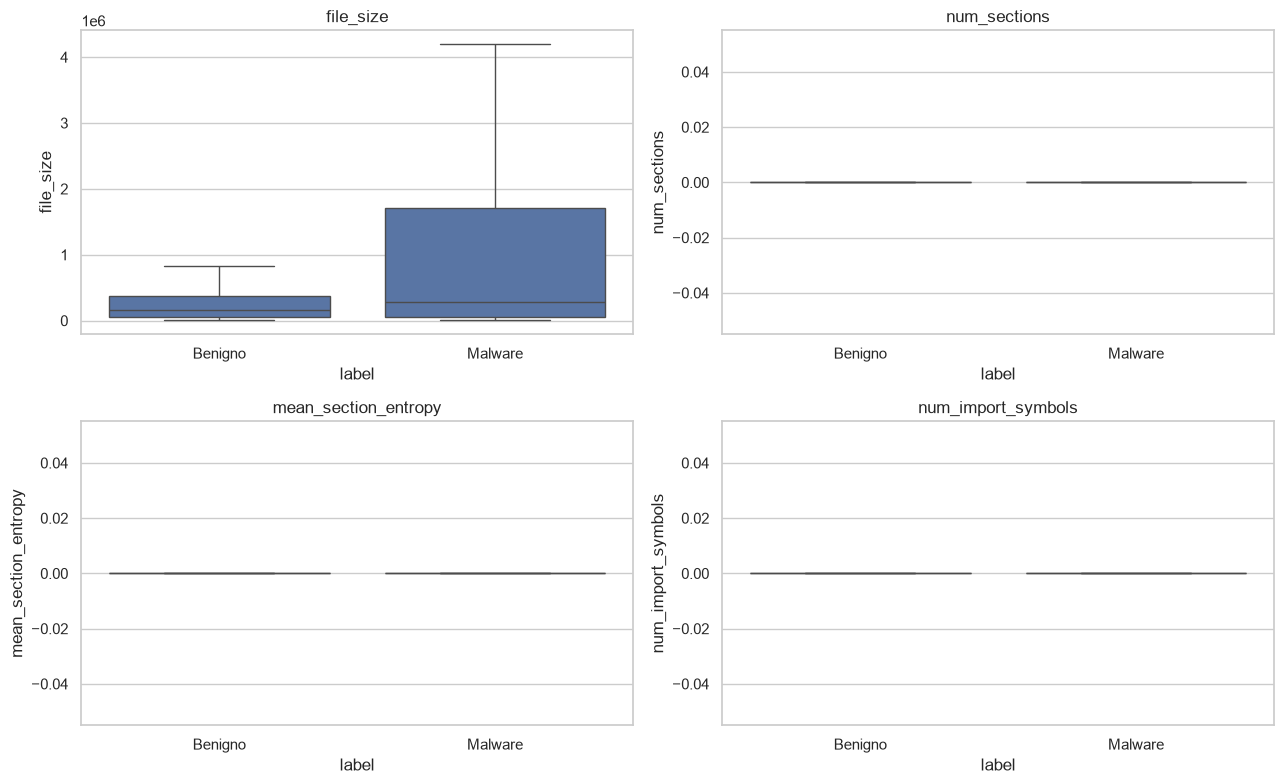

In [7]:
cols_entropia = [c for c in features_entropia if c.startswith('sec_entropy_')]
eda = pd.DataFrame({
    'label': y.map({0: 'Benigno', 1: 'Malware'}),
    'file_size': X['filesize'],
    'num_sections': X['number_of_sections'],
    'mean_section_entropy': X[cols_entropia].mean(axis=1),
    'num_import_symbols': X['number_of_import_symbols']
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, coluna in zip(axes.ravel(), eda.columns[1:]):
    sns.boxplot(data=eda, x='label', y=coluna, ax=ax, showfliers=False)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

### Discussão rápida

- Quais features parecem separar as classes?
- - Só o tamanho do arquivo mostra diferença: a mediana do malware (~276 KB) é maior que a do benigno (~157 KB), com dispersão muito maior. Os boxplots de número de seções, entropia média e número de imports ficaram achatados em zero nas duas classes.

- Essa diferença pode ser causada pela forma de coleta?
- - Sim. Todos os benignos vieram de *Program Files* do Windows 7 e 8, e os malwares vieram do VxHeaven e do VirusTotal. Tamanho e estrutura do arquivo refletem compilador, época e tipo de software de cada fonte

- Qual delas seria fácil para um atacante manipular?
- - O tamanho do arquivo: basta acrescentar dados inúteis (padding ou overlay) no final do executável, sem mudar nada do comportamento. Campos de cabeçalho e alinhamento também mudam com uma simples recompilação.

- Ausência de um import significa ausência daquela capacidade?
- - Não. O malware pode carregar funções em tempo de execução (LoadLibrary/GetProcAddress), usar packers que escondem a tabela de imports ou chamar o sistema diretamente. Nesta base, o zero nem sequer indica ausência: todas as amostras têm zero imports, o que só é possível se o dado estiver faltando.

## 5. Separar treino, validação e teste

O teste será usado **uma única vez**, depois que o modelo e o limiar estiverem definidos.

- treino: 60%;
- validação: 20%;
- teste: 20%.

Usamos estratificação porque a classe malware é majoritária.

In [8]:
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_treino_val, y_treino_val, test_size=0.25,
    stratify=y_treino_val, random_state=RANDOM_SEED
)

print('Treino   :', X_treino.shape, 'malware:', f'{y_treino.mean():.1%}')
print('Validação:', X_valid.shape,  'malware:', f'{y_valid.mean():.1%}')
print('Teste    :', X_teste.shape,  'malware:', f'{y_teste.mean():.1%}')

Treino   : (3748, 28) malware: 90.5%
Validação: (1250, 28) malware: 90.5%
Teste    : (1250, 28) malware: 90.5%


## 6. Baseline: prever sempre a classe majoritária

Como malware é majoritário, um modelo que sempre responde “malware” pode ter acurácia alta. O baseline revela quanto o modelo precisa superar.

In [9]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_treino, y_treino)
pred_dummy = dummy.predict(X_valid)

print(classification_report(y_valid, pred_dummy, target_names=['Benigno', 'Malware'], zero_division=0))
print('O baseline detecta malware, mas bloqueia todos os benignos.')

              precision    recall  f1-score   support

     Benigno       0.00      0.00      0.00       119
     Malware       0.90      1.00      0.95      1131

    accuracy                           0.90      1250
   macro avg       0.45      0.50      0.48      1250
weighted avg       0.82      0.90      0.86      1250

O baseline detecta malware, mas bloqueia todos os benignos.


## 7. Treinar o Random Forest

Usamos pesos balanceados para evitar que a classe majoritária domine as árvores. O foco ainda não é otimizar hiperparâmetros.

In [10]:
modelo = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
modelo.fit(X_treino, y_treino)

proba_valid = modelo.predict_proba(X_valid)[:, 1]
pred_valid_05 = (proba_valid >= 0.50).astype(int)

print(classification_report(y_valid, pred_valid_05, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_valid, proba_valid):.3f}')
print('PR-AUC :', f'{average_precision_score(y_valid, proba_valid):.3f}')

              precision    recall  f1-score   support

     Benigno       0.54      0.88      0.67       119
     Malware       0.99      0.92      0.95      1131

    accuracy                           0.92      1250
   macro avg       0.76      0.90      0.81      1250
weighted avg       0.94      0.92      0.92      1250

ROC-AUC: 0.964
PR-AUC : 0.995


## 8. Matriz de confusão na validação

Neste contexto:

- **falso negativo:** malware classificado como benigno;
- **falso positivo:** programa benigno classificado como malware.

Um antivírus precisa controlar os dois: deixar malware passar é perigoso, mas bloquear software legítimo também pode interromper a operação.

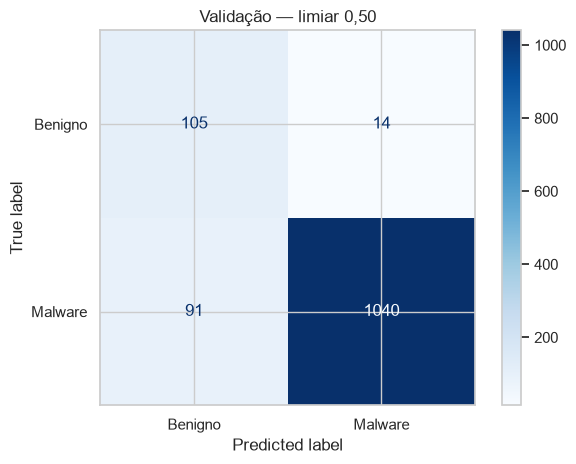

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, pred_valid_05,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Validação — limiar 0,50')
plt.tight_layout()
plt.show()

## 9. Escolher o limiar usando apenas a validação

Vamos procurar o menor limiar que alcance **recall de malware ≥ 95%** e, entre os candidatos, escolher aquele com maior precisão.

Essa regra é uma decisão didática. Em produção, o alvo deve vir do custo e da capacidade do SOC.

Limiar escolhido na validação: 0.37


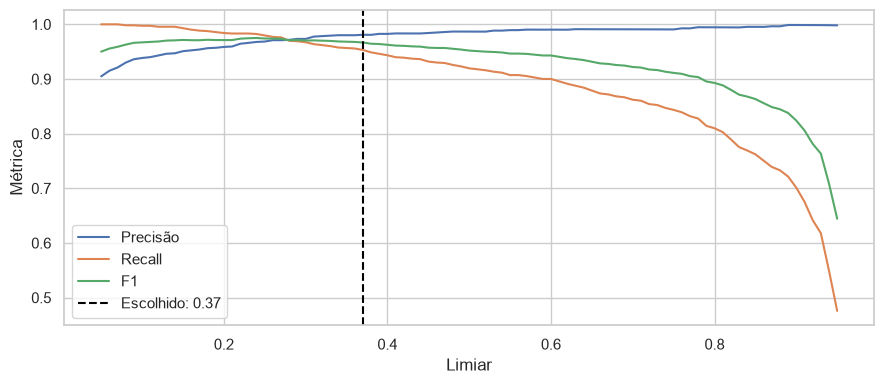

In [12]:
linhas = []
for limiar in np.arange(0.05, 0.96, 0.01):
    pred = (proba_valid >= limiar).astype(int)
    linhas.append({
        'limiar': limiar,
        'precisao': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred),
        'f1': f1_score(y_valid, pred)
    })

tabela_lim = pd.DataFrame(linhas)
candidatos = tabela_lim[tabela_lim['recall'] >= 0.95]
if len(candidatos):
    LIMIAR = candidatos.sort_values(['precisao', 'limiar'], ascending=[False, False]).iloc[0]['limiar']
else:
    LIMIAR = tabela_lim.loc[tabela_lim['f1'].idxmax(), 'limiar']

print('Limiar escolhido na validação:', round(float(LIMIAR), 2))

plt.figure(figsize=(9, 4))
plt.plot(tabela_lim['limiar'], tabela_lim['precisao'], label='Precisão')
plt.plot(tabela_lim['limiar'], tabela_lim['recall'], label='Recall')
plt.plot(tabela_lim['limiar'], tabela_lim['f1'], label='F1')
plt.axvline(LIMIAR, color='black', ls='--', label=f'Escolhido: {LIMIAR:.2f}')
plt.xlabel('Limiar')
plt.ylabel('Métrica')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Avaliação final — agora podemos abrir o teste

Depois desta célula, não altere o modelo ou o limiar com base no resultado do teste. Se alterarmos, o teste deixa de ser independente.

Limiar: 0.37
              precision    recall  f1-score   support

     Benigno       0.70      0.83      0.76       119
     Malware       0.98      0.96      0.97      1131

    accuracy                           0.95      1250
   macro avg       0.84      0.90      0.87      1250
weighted avg       0.96      0.95      0.95      1250

ROC-AUC: 0.973
PR-AUC : 0.997


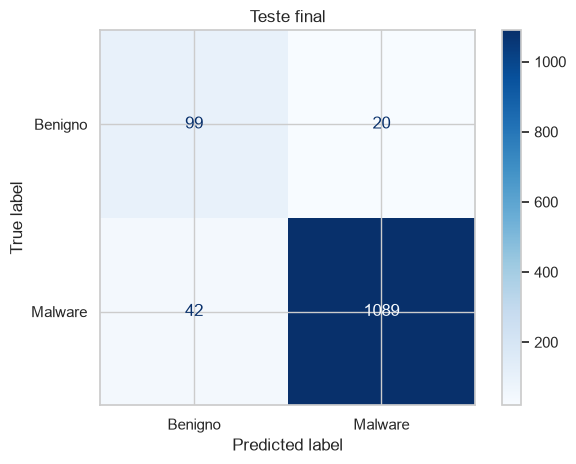

In [13]:
proba_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= LIMIAR).astype(int)

print('Limiar:', round(float(LIMIAR), 2))
print(classification_report(y_teste, pred_teste, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_teste, proba_teste):.3f}')
print('PR-AUC :', f'{average_precision_score(y_teste, proba_teste):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_teste, pred_teste,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Teste final')
plt.tight_layout()
plt.show()

## 11. Quais features o modelo utilizou?

A importância do Random Forest indica quanto uma feature ajudou as árvores a reduzir impureza.

> **Importância não é causalidade.** Uma feature importante pode representar viés de coleta ou uma regularidade fácil de evadir.

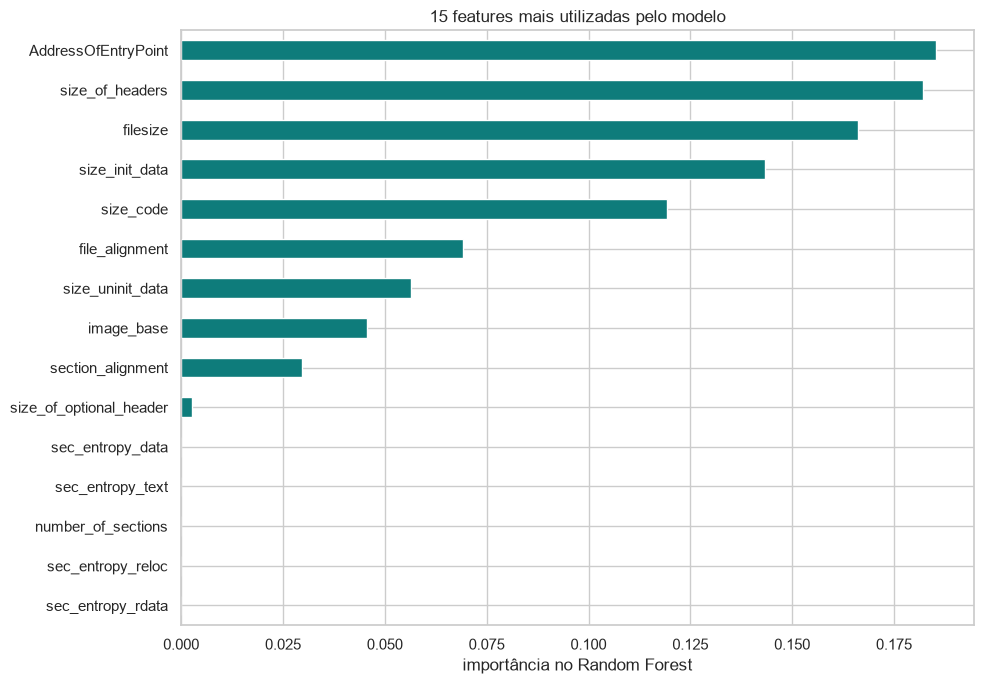

,importancia
AddressOfEntryPoint,0.185375
size_of_headers,0.182059
filesize,0.166213
size_init_data,0.143289
size_code,0.119337
file_alignment,0.069307
size_uninit_data,0.056456
image_base,0.045650
section_alignment,0.029684
size_of_optional_header,0.002629


In [14]:
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importancias.head(15).sort_values().plot(kind='barh', color='#0E7C7B')
plt.title('15 features mais utilizadas pelo modelo')
plt.xlabel('importância no Random Forest')
plt.tight_layout()
plt.show()

importancias.head(15).to_frame('importancia')

### Perguntas para discussão

- As features do topo fazem sentido para malware?
- - Pouco. As cinco primeiras (AddressOfEntryPoint, size_of_headers, filesize, size_init_data, size_code) somam cerca de 80% da importância e descrevem tamanho e layout do arquivo, não comportamento malicioso. As features que teriam mais sentido, entropia e imports de APIs como VirtualAlloc e WriteProcessMemory, tiveram importância zero porque estão zeradas na base.

- Alguma pode denunciar o ambiente ou a fonte de coleta?
- - Sim, principalmente image_base, file_alignment, section_alignment e size_of_headers. Esses valores dependem do compilador, do linker e da época do software.

- O que aconteceria se o atacante alterasse apenas essa feature?
- - Como o modelo se apoia em poucas features estruturais e baratas de mudar, alterar o tamanho do arquivo ou o entry point, sem mudar o comportamento, poderia empurrar a probabilidade para baixo do limiar de 0,46 e fazer o malware passar como benigno.

- Duas features parecidas podem dividir importância entre si?
- - Sim. filesize, size_code e size_init_data medem tamanhos correlacionados, e o entry point costuma ficar dentro da seção de código.

## 12. Ablação por famílias de features

Vamos comparar grupos de features usando validação cruzada somente no conjunto de treino + validação. O objetivo é avaliar quanto cada família contribui.

In [15]:
grupos = {
    'Estrutura': features_estrutura,
    'Entropia/seções': features_entropia,
    'Imports/capacidades': features_imports,
    'Todas': features
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados = []

for nome, cols in grupos.items():
    m = RandomForestClassifier(
        n_estimators=150, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1,
        random_state=RANDOM_SEED
    )
    scores = cross_validate(
        m, X_treino_val[cols], y_treino_val,
        cv=cv, scoring={'recall': 'recall', 'f1': 'f1', 'pr_auc': 'average_precision'},
        n_jobs=-1
    )
    resultados.append({
        'grupo': nome,
        'recall_medio': scores['test_recall'].mean(),
        'f1_medio': scores['test_f1'].mean(),
        'pr_auc_media': scores['test_pr_auc'].mean()
    })

pd.DataFrame(resultados).set_index('grupo').round(3)

,recall_medio,f1_medio,pr_auc_media
grupo,,,
Estrutura,0.941,0.962,0.997
Entropia/seções,0.600,0.570,0.905
Imports/capacidades,0.600,0.570,0.905
Todas,0.931,0.958,0.996


## 13. Limitações que precisam acompanhar o resultado

1. **Viés de origem:** benignos e maliciosos foram coletados de fontes diferentes.
2. **Idade:** parte dos dados representa software e malware antigos.
3. **Split aleatório:** variantes próximas podem aparecer em treino e teste.
4. **Rótulo:** “malware” depende do processo de rotulagem usado pelos autores.
5. **Evasão:** um atacante pode alterar features estáticas sem mudar o comportamento.

Para um projeto mais robusto, use uma base temporal como BODMAS ou EMBER e faça divisão por tempo, família e campanha.

## 14. Exportar features para o Splunk (opcional)

Vamos produzir um CSV pequeno, sem hashes ou executáveis. Os nomes das colunas abaixo serão usados nos comandos SPL.

In [16]:
splunk_df = pd.DataFrame({
    'sample_id': df['sample_id'],
    'label': df['label'].map({0: 'benign', 1: 'malicious'}),
    'file_size': pd.to_numeric(df['filesize'], errors='coerce').fillna(0),
    'entropy': df[cols_entropia].apply(pd.to_numeric, errors='coerce').fillna(0).mean(axis=1),
    'num_sections': pd.to_numeric(df['number_of_sections'], errors='coerce').fillna(0),
    'num_imports': pd.to_numeric(df['number_of_import_symbols'], errors='coerce').fillna(0),
    'size_code': pd.to_numeric(df['size_code'], errors='coerce').fillna(0),
    'entry_point': pd.to_numeric(df['AddressOfEntryPoint'], errors='coerce').fillna(0),
    'has_virtual_alloc': (pd.to_numeric(df['VirtualAlloc'], errors='coerce').fillna(0) > 0).astype(int),
    'has_write_process_memory': (pd.to_numeric(df['WriteProcessMemory'], errors='coerce').fillna(0) > 0).astype(int)
})

CAMINHO_SPLUNK = str(BASE_DIR / 'malware_features.csv')
splunk_df.to_csv(CAMINHO_SPLUNK, index=False)
print('Arquivo salvo em:', CAMINHO_SPLUNK)
print('Dimensões:', splunk_df.shape)
splunk_df.head()

Arquivo salvo em: Aula 5/malware_features.csv
Dimensões: (6248, 10)


,sample_id,label,file_size,entropy,num_sections,num_imports,size_code,entry_point,has_virtual_alloc,has_write_process_memory
0,0,benign,57434,0.0,0,0,10752,12810,0,0
1,1,benign,44420,0.0,0,0,8192,10505,0,0
2,2,benign,20706,0.0,0,0,3072,5442,0,0
3,3,benign,69110,0.0,0,0,19456,19525,0,0
4,4,benign,39574,0.0,0,0,8192,9788,0,0


In [17]:
# Baixar o CSV no navegador do Colab
try:
    from google.colab import files
    files.download(CAMINHO_SPLUNK)
except ImportError:
    print('Fora do Colab: arquivo disponível em', CAMINHO_SPLUNK)

Fora do Colab: arquivo disponível em Aula 5/malware_features.csv


## 15. SPL correspondente no Splunk AI Toolkit (opcional)

Depois de enviar o arquivo como lookup:

### Treinar e salvar

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number<=70
| fit RandomForestClassifier label from file_size entropy num_sections num_imports size_code entry_point has_virtual_alloc has_write_process_memory into malware_rf_v1
```

### Aplicar no teste

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number>70
| apply malware_rf_v1 as predicao
| `confusionmatrix(label, predicao)`
```

> O split com `sample` é adequado para a demonstração. Em produção, carregue uma coluna de tempo/campanha e preserve o futuro como teste.

## AV1 — Experimentos (antes × depois)

Faço duas alterações neste notebook, sem editar as células originais (elas são o "antes"):

- **Alteração 1 — Dados e Features:** retiro as features zeradas (1a) e, em seguida, também as que podem denunciar a origem da coleta (1b).
- **Alteração 2 — Avaliação:** troco o split aleatório por um split **por procedência do malware** (treino numa fonte, teste na outra), para medir a generalização sem vazamento de fonte.

Regras que sigo: mesmo `RANDOM_SEED` e mesmos hiperparâmetros do Random Forest. Na Alteração 1 o limiar é escolhido **só na validação** e o teste apenas reporta; na Alteração 2 comparo o poder de discriminação por **PR-AUC/ROC-AUC**, que independem de limiar.

**Preparação e linha de base.** Defino a mesma regra de limiar da seção 9 como função (`escolher_limiar`) e uma função `resumo` que extrai do teste as métricas que vou comparar: recall de cada classe, FN, FP, PR-AUC e ROC-AUC.
A primeira linha da tabela é o modelo original com o limiar da aula, ou seja, o "antes".

In [18]:
# === AV1 — Experimentos (antes × depois) ===
LIMS = np.arange(0.05, 0.96, 0.01)

def escolher_limiar(y, p):
    """Mesma regra da seção 9: recall >= 95% com maior precisão; senão, maior F1."""
    tab = pd.DataFrame([{'limiar': l,
                         'precisao': precision_score(y, (p >= l).astype(int), zero_division=0),
                         'recall': recall_score(y, (p >= l).astype(int)),
                         'f1': f1_score(y, (p >= l).astype(int))} for l in LIMS])
    cand = tab[tab.recall >= 0.95]
    if len(cand):
        return float(cand.sort_values(['precisao', 'limiar'], ascending=[False, False]).iloc[0].limiar)
    return float(tab.loc[tab.f1.idxmax(), 'limiar'])

def resumo(nome, y, p, limiar, n_feat):
    tn, fp, fn, tp = confusion_matrix(y, (p >= limiar).astype(int)).ravel()
    return {'experimento': nome, 'n_features': n_feat, 'limiar': round(limiar, 2),
            'recall_malware': round(tp / (tp + fn), 3), 'recall_benigno': round(tn / (tn + fp), 3),
            'FN (malware liberado)': fn, 'FP (benigno bloqueado)': fp,
            'PR-AUC': round(average_precision_score(y, p), 3), 'ROC-AUC': round(roc_auc_score(y, p), 3)}

proba_teste = modelo.predict_proba(X_teste)[:, 1]
resultados_av1 = [resumo('Original (28 features)', y_teste, proba_teste, LIMIAR, len(features))]
pd.DataFrame(resultados_av1)

,experimento,n_features,limiar,recall_malware,recall_benigno,FN (malware liberado),FP (benigno bloqueado),PR-AUC,ROC-AUC
0,Original (28 features),28,0.37,0.963,0.832,42,20,0.997,0.973


**Alteração 1 — Dados e Features.** Retreino o mesmo Random Forest em duas variantes: **1a** sem as 18 features zeradas (entropia, imports e `number_of_sections`) e **1b** também sem as 5 features de layout que podem marcar a fonte da coleta (`image_base`, alinhamentos e cabeçalhos).
A pergunta é se o modelo detecta malware ou detecta de onde o arquivo veio. Se a 1b cair muito, ele dependia da assinatura da fonte.

In [19]:
features_zeradas = features_entropia + features_imports + ['number_of_sections']
features_origem  = ['image_base', 'file_alignment', 'section_alignment',
                    'size_of_headers', 'size_of_optional_header']

variantes = {
    'Alt. 1a: sem zeradas':              [c for c in features if c not in features_zeradas],
    'Alt. 1b: sem zeradas e sem origem': [c for c in features if c not in features_zeradas + features_origem],
}

for nome, cols in variantes.items():
    m = RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight='balanced',
                               n_jobs=-1, random_state=RANDOM_SEED).fit(X_treino[cols], y_treino)
    lim = escolher_limiar(y_valid, m.predict_proba(X_valid[cols])[:, 1])   # limiar só na validação
    resultados_av1.append(resumo(nome, y_teste, m.predict_proba(X_teste[cols])[:, 1], lim, len(cols)))
    print(nome, '->', cols)

pd.DataFrame(resultados_av1)

Alt. 1a: sem zeradas -> ['filesize', 'size_code', 'size_init_data', 'size_uninit_data', 'size_of_headers', 'size_of_optional_header', 'AddressOfEntryPoint', 'image_base', 'section_alignment', 'file_alignment']
Alt. 1b: sem zeradas e sem origem -> ['filesize', 'size_code', 'size_init_data', 'size_uninit_data', 'AddressOfEntryPoint']


,experimento,n_features,limiar,recall_malware,recall_benigno,FN (malware liberado),FP (benigno bloqueado),PR-AUC,ROC-AUC
0,Original (28 features),28,0.37,0.963,0.832,42,20,0.997,0.973
1,Alt. 1a: sem zeradas,10,0.40,0.958,0.832,48,20,0.997,0.974
2,Alt. 1b: sem zeradas e sem origem,5,0.41,0.959,0.588,46,49,0.994,0.944


**Alteração 2 — Avaliação: split por procedência (sem vazamento de fonte).** O split aleatório deixa o malware de VxHeaven e o do VirusTotal se misturarem entre treino e teste; variantes próximas da mesma coleção podem vazar e inflar o PR-AUC. Aqui treino com o malware de **uma** fonte e testo no da **outra** (o benigno, que vem de uma única fonte, eu divido ao meio), mantendo seed e hiperparâmetros. Como não defino uma validação separada, comparo o **PR-AUC/ROC-AUC** (independentes de limiar) e mostro o recall a 0,50 só como ilustração. A pergunta é se o detector generaliza para malware de outra procedência ou só reconhece a "cara" da coleção onde treinou — é o teste de estresse do viés de origem da Alteração 1.

In [20]:
# === Alteração 2 — Avaliação: split por procedência do malware (sem vazamento de fonte) ===
# X preserva o índice de df (concat com ignore_index), então recupero a fonte de cada amostra:
fonte = df.loc[X.index, 'source_dataset']
BENIGNO    = 'staDynBenignLab'
FONTES_MAL = {'VirusTotal': 'staDynVt2955Lab', 'VxHeaven': 'staDynVxHeaven2698Lab'}

def split_por_fonte(tag_teste):
    """Benigno dividido 50/50; malware da fonte-alvo vai p/ teste e o da outra fonte p/ treino."""
    ben = X.index[fonte == BENIGNO]
    ben_tr, ben_te = train_test_split(ben, test_size=0.5, random_state=RANDOM_SEED)
    tr = X.index[(fonte != BENIGNO) & (fonte != tag_teste)].union(ben_tr)
    te = X.index[fonte == tag_teste].union(ben_te)
    return tr, te

resultados_proc = []
for nome, tag in FONTES_MAL.items():
    tr, te = split_por_fonte(tag)
    m = RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight='balanced',
                               n_jobs=-1, random_state=RANDOM_SEED).fit(X.loc[tr], y.loc[tr])
    p = m.predict_proba(X.loc[te])[:, 1]
    resultados_proc.append(resumo(f'Malware de teste: {nome} (treino na outra fonte)',
                                  y.loc[te], p, 0.50, len(features)))
    print(f'{nome:>11}: treino {len(tr)}  teste {len(te)}  (malware no teste: {int(y.loc[te].sum())})')

tabela_proc = pd.DataFrame(resultados_proc)
tabela_proc

 VirusTotal: treino 2995  teste 3253  (malware no teste: 2955)


   VxHeaven: treino 3252  teste 2996  (malware no teste: 2698)


,experimento,n_features,limiar,recall_malware,recall_benigno,FN (malware liberado),FP (benigno bloqueado),PR-AUC,ROC-AUC
0,Malware de teste: VirusTotal (treino na outra ...,28,0.5,0.606,0.943,1163,17,0.982,0.871
1,Malware de teste: VxHeaven (treino na outra fo...,28,0.5,0.867,0.799,360,60,0.984,0.901


**Comparação com o split aleatório.** Junto a linha do modelo original (split aleatório estratificado, o "antes") com as duas direções do split por procedência. Se o PR-AUC/ROC-AUC caírem quando treino e teste vêm de fontes diferentes, parte do desempenho do split aleatório vinha de reconhecer a procedência, e não malware em geral.

In [21]:
# Antes (split aleatório) x depois (split por procedência) — foco em PR-AUC/ROC-AUC
cols_cmp = ['experimento', 'PR-AUC', 'ROC-AUC', 'recall_malware', 'recall_benigno',
            'FN (malware liberado)', 'FP (benigno bloqueado)']
comparacao_proc = pd.DataFrame([resultados_av1[0]] + resultados_proc)[cols_cmp]
comparacao_proc

,experimento,PR-AUC,ROC-AUC,recall_malware,recall_benigno,FN (malware liberado),FP (benigno bloqueado)
0,Original (28 features),0.997,0.973,0.963,0.832,42,20
1,Malware de teste: VirusTotal (treino na outra ...,0.982,0.871,0.606,0.943,1163,17
2,Malware de teste: VxHeaven (treino na outra fo...,0.984,0.901,0.867,0.799,360,60


## Conclusão da AV1

**Alteração 1a (sem features zeradas) vs original:** recall de malware 0,958 vs 0,963, recall de benigno 0,832 vs 0,832, PR-AUC 0,997 vs 0,997 (ROC-AUC 0,974 vs 0,973). Tirar as 18 colunas zeradas praticamente não mudou nada (FN 48 vs 42, FP 20 vs 20). Isso confirma que essas colunas não traziam informação e que o modelo original já decidia só com as 10 features de estrutura.

**Alteração 1b (sem zeradas e sem origem) vs original:** recall de malware 0,959, recall de benigno 0,588 (era 0,832), PR-AUC 0,994, ROC-AUC 0,944 (era 0,973). Os falsos positivos mais que dobraram (49 vs 20). Sem `image_base`, alinhamentos e tamanhos de cabeçalho, o modelo perde boa parte da capacidade de reconhecer os benignos. Essas features de layout funcionam como uma assinatura de *Program Files* do Windows 7/8 e não como sinal de comportamento malicioso, o que indica dependência do viés de origem da coleta.

**Alteração 2 (split por procedência) vs split aleatório:** no split aleatório o modelo tem PR-AUC 0,997, ROC-AUC 0,973 e recall de malware 0,963. Treinando em uma fonte de malware e testando na outra, o desempenho piora de forma clara. Treino em VxHeaven e teste em VirusTotal: PR-AUC 0,982, ROC-AUC 0,871 e recall de malware a 0,50 de apenas 0,606 — o modelo deixa passar cerca de 39% do malware. Treino em VirusTotal e teste em VxHeaven: PR-AUC 0,984, ROC-AUC 0,901 e recall de malware 0,867. O PR-AUC cai pouco porque cada teste ainda é ~90% malware (piso alto), mas o ROC-AUC e, sobretudo, o recall de malware a 0,50 caem bastante. Ou seja, parte do desempenho do split aleatório vinha de reconhecer variantes próximas da mesma coleção (vazamento de fonte); o modelo não generaliza bem para malware de outra procedência, o que reforça o viés de origem visto na Alteração 1.

## Entregável da aula

- [ ] Base real carregada e origem dos dados documentada.
- [ ] Conjunto de features justificado por famílias.
- [ ] Treino, validação e teste separados antes da modelagem.
- [ ] Baseline e Random Forest comparados.
- [ ] Limiar escolhido somente na validação.
- [ ] Teste final executado uma única vez.
- [ ] Importâncias e riscos de leakage discutidos.
- [ ] Respostas das perguntas registradas no notebook.